# 1-1


In [ ]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


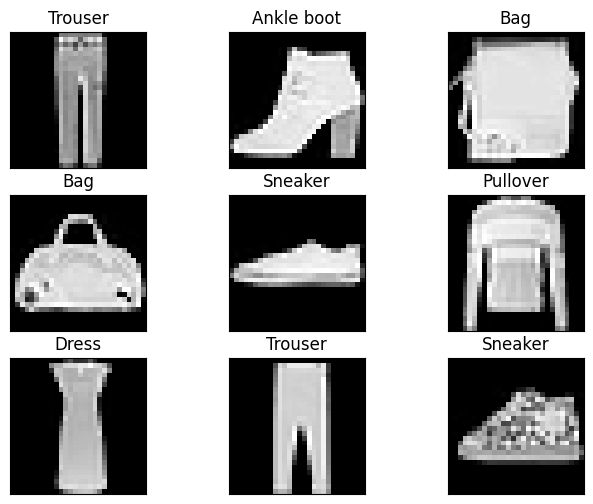

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
class_names = ['T-shirt/top', 'Trouser', 'Pullover',
 'Dress', 'Coat', 'Sandal',
 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
samples = np.random.randint(len(X_train), size=9)

plt.figure(figsize = (8, 6))
for i, idx in enumerate(samples):
  plt.subplot(3, 3, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(X_train[idx], cmap = 'gray')
  plt.title(class_names[y_train[idx]])
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
 X_train, y_train, test_size = 0.3, random_state = 42)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(42000, 28, 28) (42000,)
(18000, 28, 28) (18000,)


In [ ]:
import numpy as np

X_train = X_train.astype('float32') / 255.
X_val = X_val.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

print(np.max(X_train), np.min(X_train))

1.0 0.0


In [ ]:
print('X_train : ', X_train.shape)
print('X_val : ', X_val.shape)
print('X_test : ', X_test.shape)

X_train :  (42000, 28, 28)
X_val :  (18000, 28, 28)
X_test :  (10000, 28, 28)


In [ ]:
import tensorflow as tf

X_train = X_train[..., tf.newaxis]
X_val = X_val[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]

print('X_train : ', X_train.shape)
print('X_val : ', X_val.shape)
print('X_test : ', X_test.shape)

X_train :  (42000, 28, 28, 1)
X_val :  (18000, 28, 28, 1)
X_test :  (10000, 28, 28, 1)


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

def build_model():
  model = keras.Sequential()
  model.add(layers.Conv2D(filters=16, kernel_size= 3,
                          strides=(1, 1), padding='same', activation='relu',
                          input_shape=(28, 28, 1)))
  model.add(layers.MaxPool2D(pool_size=(2, 2), strides=2))
  model.add(layers.Conv2D(filters=32, kernel_size= 3,
                          strides=(1, 1), padding='same', activation='relu'))
  model.add(layers.MaxPool2D(pool_size=(2, 2), strides=2))
  model.add(layers.Conv2D(filters=64, kernel_size= 3,
                          strides=(1, 1), padding='same', activation='relu'))
  model.add(layers.MaxPool2D(pool_size=(2, 2), strides=2))
  model.add(layers.Flatten())
  model.add(layers.Dense(64, activation = 'relu'))
  model.add(layers.Dense(10, activation = 'softmax'))
  return model

In [ ]:
model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,874 (237.79 KB)

 Trainable params: 60,874 (237.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
adam = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=adam,
      loss = 'sparse_categorical_crossentropy',
      metrics=['acc'])

In [ ]:
EPOCHS = 30
BATCH_SIZE = 64
history = model.fit(X_train, y_train,
         epochs = EPOCHS,
         batch_size = BATCH_SIZE,
         validation_data = (X_val, y_val),
         verbose = 1)

Epoch 1/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - acc: 0.7780 - loss: 0.6033 - val_acc: 0.8493 - val_loss: 0.4226
Epoch 2/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - acc: 0.8627 - loss: 0.3757 - val_acc: 0.8672 - val_loss: 0.3600
Epoch 3/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.8835 - loss: 0.3200 - val_acc: 0.8855 - val_loss: 0.3178
Epoch 4/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - acc: 0.8948 - loss: 0.2869 - val_acc: 0.8929 - val_loss: 0.2893
Epoch 5/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.9047 - loss: 0.2612 - val_acc: 0.8989 - val_loss: 0.2783
Epoch 6/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - acc: 0.9110 - loss: 0.2417 - val_acc: 0.9018 - val_loss: 0.2676
Epoch 7/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - acc: 0.9184 - loss: 0.2241 - val_acc: 0.9104 - val_loss: 0.2474
Epoch 8/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9234 - loss: 0.2088 - val_acc: 0.9141 - val_loss: 0.2431
Epoch 9/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - 

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure(figsize=(16,8))
  plt.subplot(1,2,1)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
  plt.plot(hist['epoch'], hist['val_loss'],label = 'Val Loss')
  plt.legend()

  plt.subplot(1,2,2)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.plot(hist['epoch'], hist['acc'], label='Train Accuracy')
  plt.plot(hist['epoch'], hist['val_acc'], label = 'Val Accuracy')
  plt.legend()

  plt.show()

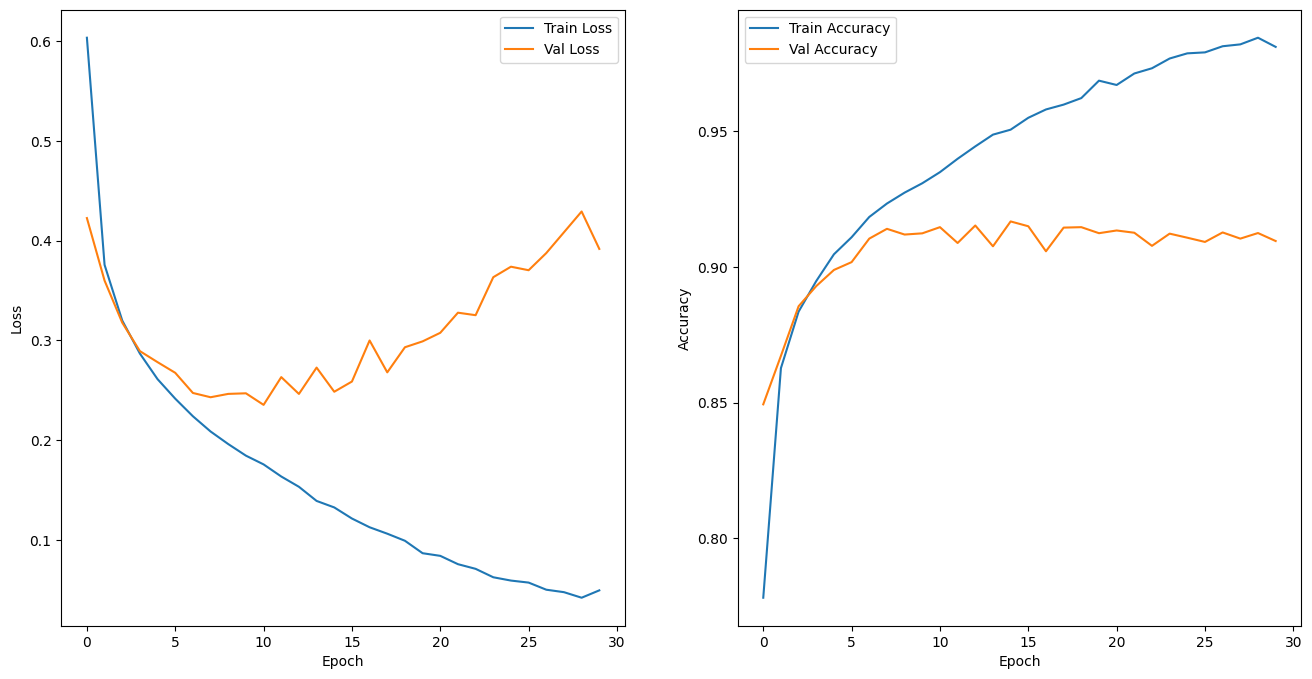

In [ ]:
plot_history(history)

# 1-2

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
def build_dropout_model():
  model = keras.Sequential()
  model.add(layers.Conv2D(filters=16, kernel_size= 3,strides=(1, 1),
                          padding='same', activation='relu',input_shape=(28, 28, 1)))
  model.add(layers.MaxPool2D(pool_size=(2, 2), strides=2))
  model.add(layers.Dropout(0.2))
  model.add(layers.Conv2D(filters=32, kernel_size= 3,
                          strides=(1, 1), padding='same', activation='relu'))
  model.add(layers.MaxPool2D(pool_size=(2, 2), strides=2))
  model.add(layers.Dropout(0.2))
  model.add(layers.Conv2D(filters=64, kernel_size= 3,
                          strides=(1, 1), padding='same', activation='relu'))
  model.add(layers.MaxPool2D(pool_size=(2, 2), strides=2))
  model.add(layers.Dropout(0.2))
  model.add(layers.Flatten())
  model.add(layers.Dense(64, activation = 'relu'))
  model.add(layers.Dense(10, activation = 'softmax'))
  return model

In [ ]:
model = build_dropout_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,874 (237.79 KB)

 Trainable params: 60,874 (237.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
      loss = 'sparse_categorical_crossentropy',
      metrics=['acc'])

In [ ]:
EPOCHS = 30
BATCH_SIZE = 64
history = model.fit(X_train, y_train,
         epochs = EPOCHS,
         batch_size = BATCH_SIZE,
         validation_data = (X_val, y_val),
         verbose = 1)

Epoch 1/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - acc: 0.7288 - loss: 0.7269 - val_acc: 0.8294 - val_loss: 0.4593
Epoch 2/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8333 - loss: 0.4581 - val_acc: 0.8661 - val_loss: 0.3669
Epoch 3/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8541 - loss: 0.3973 - val_acc: 0.8832 - val_loss: 0.3207
Epoch 4/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.8686 - loss: 0.3577 - val_acc: 0.8829 - val_loss: 0.3156
Epoch 5/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8756 - loss: 0.3380 - val_acc: 0.8922 - val_loss: 0.2913
Epoch 6/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8829 - loss: 0.3184 - val_acc: 0.9006 - val_loss: 0.2771
Epoch 7/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8876 - loss: 0.3042 - val_acc: 0.9039 - val_loss: 0.2631
Epoch 8/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.8913 - loss: 0.2922 - val_acc: 0.9059 - val_loss: 0.2582
Epoch 9/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - 

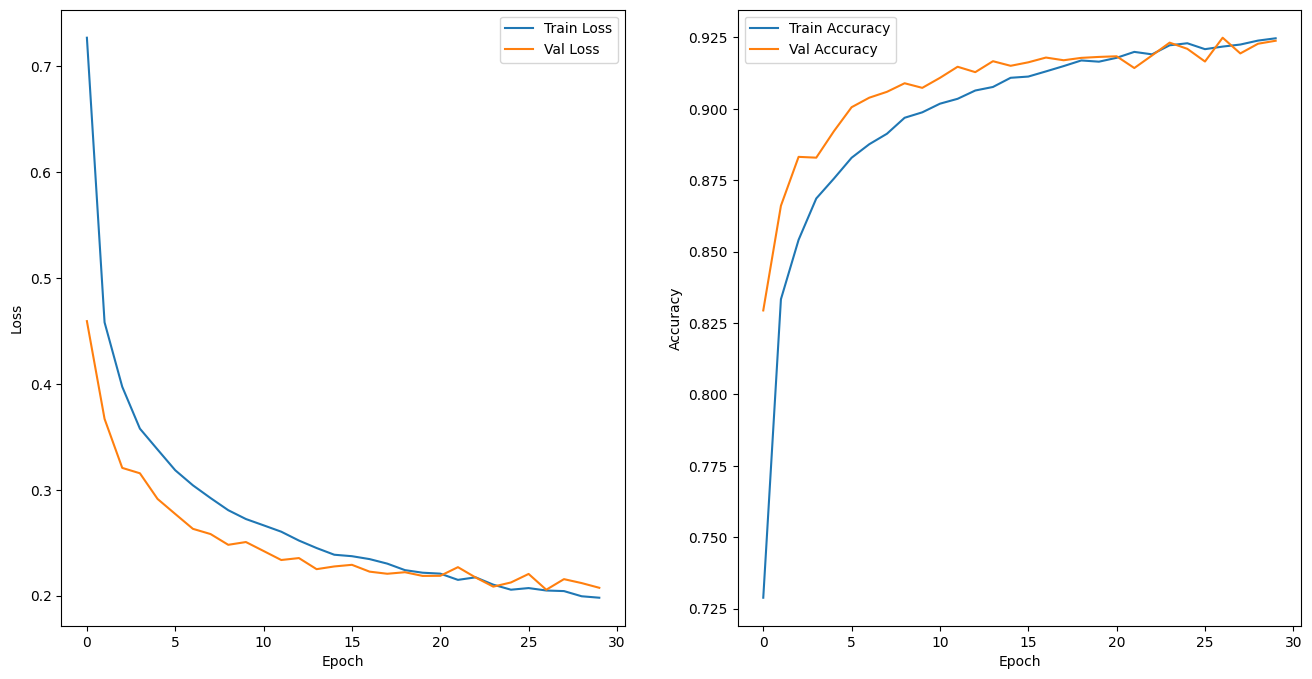

In [ ]:
plot_history(history)

In [ ]:
y_pred = model.predict(X_test)
y_pred_argmax = np.argmax(y_pred, axis=1)
y_pred_argmax[:10]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [ ]:
from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score
def print_score(y_test, y_pred):
  print('accuracy: %.3f' % (accuracy_score(y_test, y_pred)))
  print('precision: %.3f' % (precision_score(y_test, y_pred,average='macro')))
  print('recall_score: %.3f' % (recall_score(y_test, y_pred,average='macro')))
  print('f1_score: %.3f' % (f1_score(y_test, y_pred,average='macro')))

In [ ]:
print_score(y_test, y_pred_argmax)

accuracy: 0.916
precision: 0.916
recall_score: 0.916
f1_score: 0.916


# 1-3: 생략

# 1-4

In [ ]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2228s 13us/step
(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


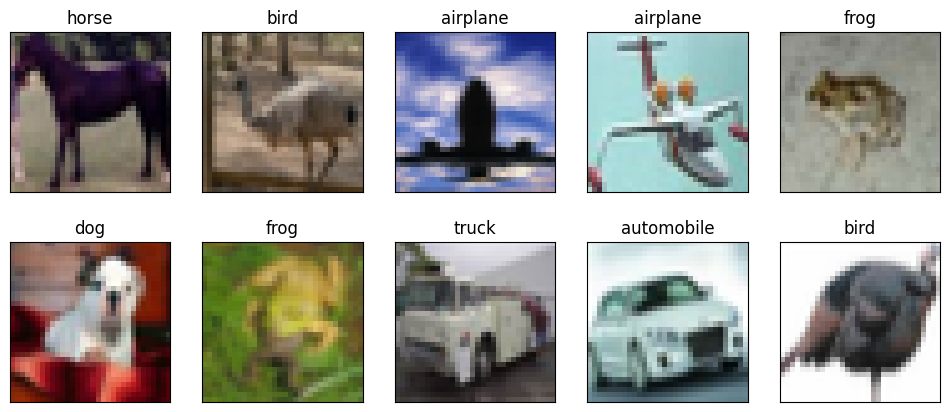

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
        'dog', 'frog', 'horse', 'ship', 'truck']

samples = np.random.randint(len(X_train), size=10)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(samples):
  plt.subplot(2, 5, i+1, xticks=[], yticks=[])
  plt.title((class_names[y_train[idx][0]]))
  plt.imshow(X_train[idx])
plt.show()

In [ ]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
 X_train, y_train, test_size = 0.3, random_state = 42)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(35000, 32, 32, 3) (35000, 1)
(15000, 32, 32, 3) (15000, 1)
(10000, 32, 32, 3) (10000, 1)


In [ ]:
y_train = y_train.reshape(-1)
y_val = y_val.reshape(-1)
y_test = y_test.reshape(-1)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(35000,)
(15000,)
(10000,)


In [ ]:
import tensorflow as tf

y_train_oh = tf.one_hot(y_train, depth=10)
y_val_oh = tf.one_hot(y_val, depth=10)
y_test_oh = tf.one_hot(y_test, depth=10)

print(y_train_oh.shape)
y_train_oh[:5]

(35000, 10)


<tf.Tensor: shape=(5, 10), dtype=float32, numpy=
array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]], dtype=float32)>

In [ ]:
y_train_oh = y_train_oh.numpy()
y_val_oh = y_val_oh.numpy()
y_test_oh = y_test_oh.numpy()

print(y_train_oh.shape)
print(y_val_oh.shape)
print(y_test_oh.shape)

(35000, 10)
(15000, 10)
(10000, 10)


In [ ]:
from tensorflow.keras import layers
def build_model():
  model = keras.Sequential()
  model.add(layers.Conv2D(32, 3, padding = 'same',
       activation='relu', input_shape = (32, 32, 3)))
  model.add(layers.MaxPooling2D(2))
  model.add(layers.Dropout(0.3))
  model.add(layers.Conv2D(64, 3, padding = 'same',
       activation='relu'))
  model.add(layers.MaxPooling2D(2))
  model.add(layers.Dropout(0.3))
  model.add(layers.Conv2D(256, 3, padding = 'same',
       activation='relu'))
  model.add(layers.MaxPooling2D(2))
  model.add(layers.Dropout(0.3))
  model.add(layers.Conv2D(256, 3, padding = 'same',
       activation='relu'))
  model.add(layers.MaxPooling2D(2))
  model.add(layers.Dropout(0.3))
  model.add(layers.Flatten())
  model.add(layers.Dense(256, activation='relu'))
  model.add(layers.Dense(10, activation='softmax'))
  return model

In [ ]:
model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 256)      │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,022,154 (3.90 MB)

 Trainable params: 1,022,154 (3.90 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
adam = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=adam,
       loss = 'categorical_crossentropy',
       metrics=['acc'])
EPOCHS = 100
BATCH_SIZE = 256
history = model.fit(X_train, y_train_oh,
         epochs = EPOCHS,
         batch_size = BATCH_SIZE,
         validation_data = (X_val, y_val_oh))

Epoch 1/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - acc: 0.1779 - loss: 2.1712 - val_acc: 0.2401 - val_loss: 2.0217
Epoch 2/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.3073 - loss: 1.8956 - val_acc: 0.3415 - val_loss: 1.8246
Epoch 3/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.3598 - loss: 1.7517 - val_acc: 0.3791 - val_loss: 1.7250
Epoch 4/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.3861 - loss: 1.6763 - val_acc: 0.4015 - val_loss: 1.6651
Epoch 5/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.4067 - loss: 1.6163 - val_acc: 0.4243 - val_loss: 1.6019
Epoch 6/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.4238 - loss: 1.5717 - val_acc: 0.4441 - val_loss: 1.5492
Epoch 7/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.4387 - loss: 1.5280 - val_acc: 0.4547 - val_loss: 1.5163
Epoch 8/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.4547 - loss: 1.4931 - val_acc: 0.4796 - val_loss: 1.4615
Epoch 9/100
137/137 ━━━━━━━━━━━━━━━━━━━

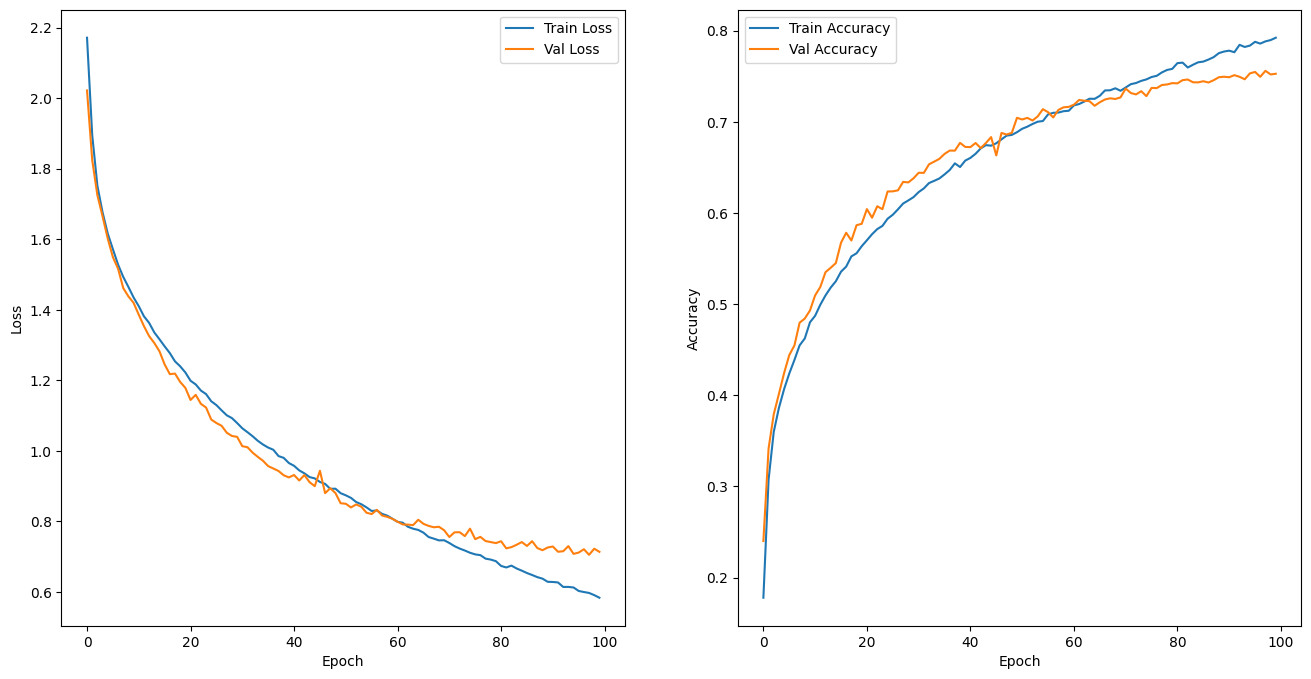

In [ ]:
plot_history(history)

In [ ]:
y_pred = model.predict(X_test)
y_pred_argmax = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
def plot_matrix(y_test, y_pred):
  plt.figure(figsize = (10, 8))
  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot = True, fmt = 'd',cmap = 'Blues')
  plt.xlabel('predicted label', fontsize = 15)
  plt.ylabel('true label', fontsize = 15)
  plt.show()

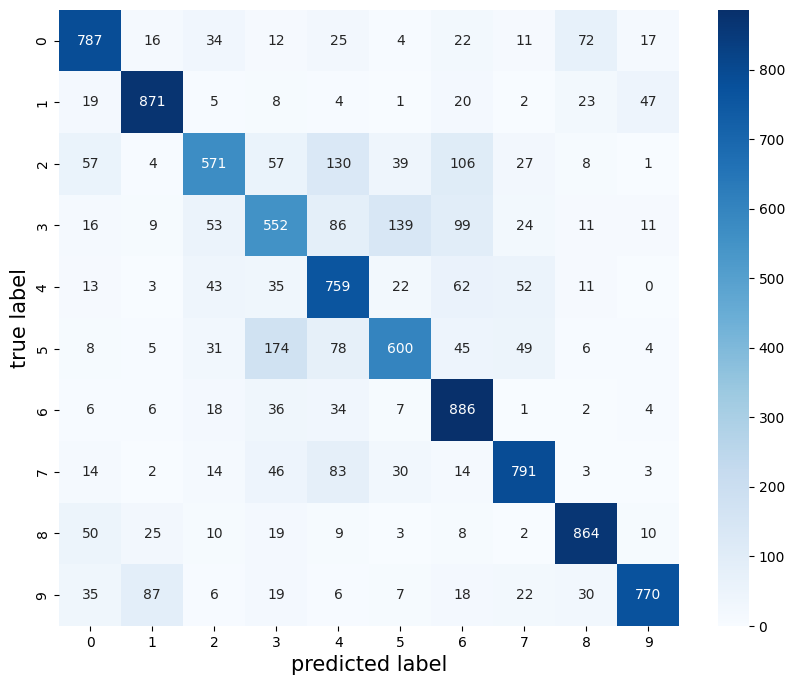

In [ ]:
plot_matrix(y_test, y_pred_argmax)

# 1-5

In [ ]:
model = build_model()
adam = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=adam,
       loss = 'categorical_crossentropy',
       metrics=['acc'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras import callbacks

checkpoint_path = 'temp/cifar_10.weights.h5'
checkpoint = callbacks.ModelCheckpoint(checkpoint_path,
             save_weights_only=True,
             save_best_only=True,
             monitor='val_loss')

In [ ]:
EPOCHS = 100
BATCH_SIZE = 256
history = model.fit(X_train, y_train_oh,
         epochs = EPOCHS,
         batch_size = BATCH_SIZE,
         validation_data = (X_val, y_val_oh),
         callbacks=[checkpoint])

Epoch 1/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - acc: 0.1795 - loss: 2.1686 - val_acc: 0.2507 - val_loss: 2.0076
Epoch 2/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.3204 - loss: 1.8379 - val_acc: 0.3533 - val_loss: 1.7823
Epoch 3/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - acc: 0.3654 - loss: 1.7242 - val_acc: 0.3762 - val_loss: 1.7061
Epoch 4/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - acc: 0.3943 - loss: 1.6518 - val_acc: 0.4009 - val_loss: 1.6497
Epoch 5/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.4145 - loss: 1.6006 - val_acc: 0.4215 - val_loss: 1.5851
Epoch 6/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.4333 - loss: 1.5539 - val_acc: 0.4463 - val_loss: 1.5401
Epoch 7/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.4448 - loss: 1.5147 - val_acc: 0.4521 - val_loss: 1.5195
Epoch 8/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - acc: 0.4596 - loss: 1.4799 - val_acc: 0.4787 - val_loss: 1.4558
Epoch 9/100
137/137 ━━━━━━━━━━━━━━━━━━━

In [ ]:
model.load_weights(checkpoint_path)

In [ ]:
y_pred = model.predict(X_test)
y_pred_argmax = np.argmax(y_pred, axis=1)

print_score(y_test, y_pred_argmax)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
accuracy: 0.758
precision: 0.757
recall_score: 0.758
f1_score: 0.755


# 1-6

In [ ]:
def build_model_bach_normalization():
  model = keras.Sequential()
  model.add(layers.Conv2D(32, 3, padding = 'same', input_shape = (32, 32, 3)))

  model.add(layers.BatchNormalization())
  model.add(layers.Activation('relu'))
  model.add(layers.MaxPooling2D(2))

  model.add(layers.Conv2D(64, 3, padding = 'same'))
  model.add(layers.BatchNormalization())
  model.add(layers.Activation('relu'))
  model.add(layers.MaxPooling2D(2))

  model.add(layers.Conv2D(256, 3, padding = 'same'))
  model.add(layers.BatchNormalization())
  model.add(layers.Activation('relu'))
  model.add(layers.MaxPooling2D(2))

  model.add(layers.Conv2D(256, 3, padding = 'same'))
  model.add(layers.BatchNormalization())
  model.add(layers.Activation('relu'))
  model.add(layers.MaxPooling2D(2))

  model.add(layers.Flatten())
  model.add(layers.Dense(256, activation='relu'))
  model.add(layers.Dense(10, activation='softmax'))
  return model

In [ ]:
model = build_model_bach_normalization()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 256)      │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,024,586 (3.91 MB)

 Trainable params: 1,023,370 (3.90 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [ ]:
adam = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=adam,
              loss = 'categorical_crossentropy',
              metrics=['acc'])

In [ ]:
EPOCHS = 100
BATCH_SIZE = 256
history = model.fit(X_train, y_train_oh,
                    epochs = EPOCHS,
                    batch_size = BATCH_SIZE,
                    validation_data = (X_val, y_val_oh))

Epoch 1/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - acc: 0.4673 - loss: 1.4971 - val_acc: 0.1142 - val_loss: 2.7903
Epoch 2/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - acc: 0.6027 - loss: 1.1263 - val_acc: 0.2259 - val_loss: 2.7701
Epoch 3/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - acc: 0.6732 - loss: 0.9481 - val_acc: 0.3675 - val_loss: 2.1269
Epoch 4/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - acc: 0.7194 - loss: 0.8208 - val_acc: 0.5585 - val_loss: 1.2578
Epoch 5/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - acc: 0.7638 - loss: 0.7082 - val_acc: 0.6139 - val_loss: 1.1092
Epoch 6/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - acc: 0.8015 - loss: 0.6124 - val_acc: 0.6455 - val_loss: 1.0254
Epoch 7/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - acc: 0.8355 - loss: 0.5251 - val_acc: 0.6527 - val_loss: 0.9998
Epoch 8/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - acc: 0.8695 - loss: 0.4428 - val_acc: 0.6751 - val_loss: 0.9589
Epoch 9/100
137/137 ━━━━━━━━━━━━━━━━━━

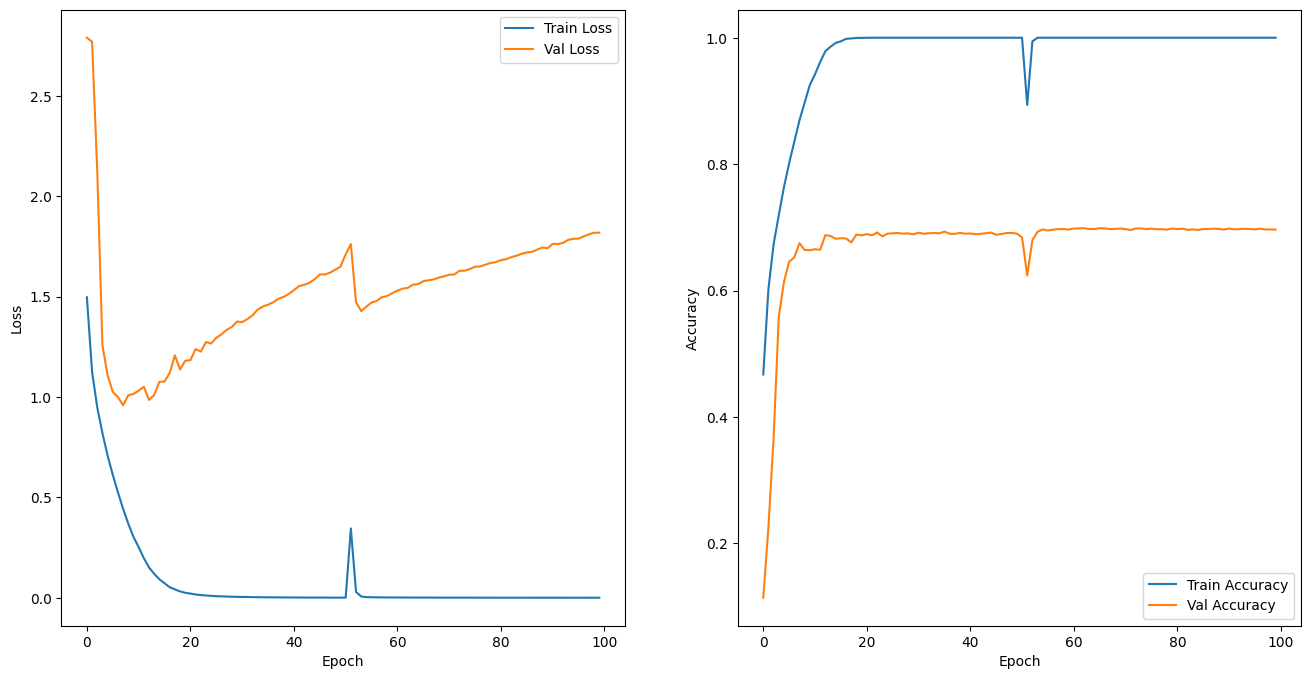

In [ ]:
plot_history(history)

In [ ]:
loss, acc = model.evaluate(X_test, y_test_oh)

print('loss : ', loss)
print('acc : ', acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.6947 - loss: 1.8382
loss :  1.8381788730621338
acc :  0.6947000026702881


# 1-7

In [1]:
import os, zipfile, shutil, random
import tensorflow as tf

# 1. 에러 없는 마이크로소프트 공식 데이터셋 다운로드 (약 786MB, 원본 25,000장)
url = 'https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip'
path_to_zip = tf.keras.utils.get_file('cats_and_dogs.zip', origin=url, extract=False)

# 2. 압축 해제할 기본 경로 설정
base_dir = './datasets/dogs-vs-cats'
os.makedirs(base_dir, exist_ok=True)

print("압축 해제 중... 잠시만 기다려줘!")
with zipfile.ZipFile(path_to_zip, 'r') as zip_ref:
    zip_ref.extractall(base_dir)

# 3. 다운로드된 원본 폴더 경로 (MS 데이터셋 기본 구조)
extracted_dir = os.path.join(base_dir, 'PetImages')
src_dirs = {'cats': os.path.join(extracted_dir, 'Cat'), 'dogs': os.path.join(extracted_dir, 'Dog')}

# 4. 교안 맞춤형 train, val, test 폴더 생성
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

for folder in [train_dir, val_dir, test_dir]:
    for cls in ['cats', 'dogs']:
        os.makedirs(os.path.join(folder, cls), exist_ok=True)

# 5. 이미지를 train(80%), val(10%), test(10%) 비율로 분할 배치
print("교안용 폴더 구조 생성 및 이미지 분할 중...")
for cls, src_path in src_dirs.items():
    # 손상된 파일이나 이미지 아닌 파일 제외하고 목록 읽기
    images = [f for f in os.listdir(src_path) if f.endswith('.jpg') and os.path.getsize(os.path.join(src_path, f)) > 0]
    random.shuffle(images)

    # 분할 개수 계산
    n_total = len(images)
    n_train = int(n_total * 0.8)
    n_val = int(n_total * 0.1)

    train_imgs = images[:n_train]
    val_imgs = images[n_train:n_train+n_val]
    test_imgs = images[n_train+n_val:]

    # 파일 이동 함수
    for img in train_imgs: shutil.move(os.path.join(src_path, img), os.path.join(train_dir, cls, img))
    for img in val_imgs: shutil.move(os.path.join(src_path, img), os.path.join(val_dir, cls, img))
    for img in test_imgs: shutil.move(os.path.join(src_path, img), os.path.join(test_dir, cls, img))

# 원본 임시 폴더 삭제 (정리)
shutil.rmtree(extracted_dir)

print("\n🎉 드디어 성공! 교안 경로 매칭 완료:")
print(f"train_dir = '{train_dir}'\nval_dir = '{val_dir}'\ntest_dir = '{test_dir}'")

압축 해제 중... 잠시만 기다려줘!
교안용 폴더 구조 생성 및 이미지 분할 중...

🎉 드디어 성공! 교안 경로 매칭 완료:
train_dir = './datasets/dogs-vs-cats/train'
val_dir = './datasets/dogs-vs-cats/val'
test_dir = './datasets/dogs-vs-cats/test'


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./ 255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='reflect')

val_datagen = ImageDataGenerator(rescale=1./ 255)
test_datagen = ImageDataGenerator(rescale=1./ 255)

In [3]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 128

train_ds = train_datagen.flow_from_directory(train_dir,
                                             batch_size=BATCH_SIZE,target_size=IMAGE_SIZE,
                                             class_mode='binary')
valid_ds = val_datagen.flow_from_directory(val_dir,
                                           batch_size=BATCH_SIZE,target_size=IMAGE_SIZE,
                                           class_mode='binary')
test_ds = test_datagen.flow_from_directory(test_dir,
                                           batch_size=BATCH_SIZE,target_size=IMAGE_SIZE,
                                           class_mode='binary')

Found 24002 images belonging to 2 classes.
Found 4765 images belonging to 2 classes.
Found 4762 images belonging to 2 classes.


In [4]:
from tensorflow import keras
from tensorflow.keras import layers
def build_model():
  model = keras.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu',
                 input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
  ])
  return model

In [5]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint_path = "./temp/dogs-vs-cats..weights.h5"
checkpoint = ModelCheckpoint(filepath=checkpoint_path,
              save_weights_only=True,
              save_best_only=True,
              monitor='val_loss',
              verbose=1)

In [ ]:
model = build_model()
model.compile(optimizer='adam',
      loss='binary_crossentropy',
      metrics=['acc'])
EPOCHS = 25
history = model.fit(train_ds,
         validation_data=valid_ds,
         epochs=EPOCHS,
         callbacks=[checkpoint])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
162/188 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - acc: 0.5318 - loss: 0.7667

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5353 - loss: 0.7572
Epoch 1: val_loss improved from None to 0.63425, saving model to ./temp/dogs-vs-cats..weights.h5

Epoch 1: finished saving model to ./temp/dogs-vs-cats..weights.h5
188/188 ━━━━━━━━━━━━━━━━━━━━ 391s 2s/step - acc: 0.5622 - loss: 0.6940 - val_acc: 0.6281 - val_loss: 0.6342
Epoch 2/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.6501 - loss: 0.6313
Epoch 2: val_loss improved from 0.63425 to 0.55955, saving model to ./temp/dogs-vs-cats..weights.h5

Epoch 2: finished saving model to ./temp/dogs-vs-cats..weights.h5
188/188 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - acc: 0.6654 - loss: 0.6153 - val_acc: 0.7018 - val_loss: 0.5595
Epoch 3/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.6955 - loss: 0.5784
Epoch 3: val_loss improved from 0.55955 to 0.50802, saving model to ./temp/dogs-vs-cats..weights.h5

Epoch 3: finished saving model to ./temp/dogs-vs-cats..weights.h5
188/188 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - acc: 0.7032 -

In [ ]:
plot_history(history)

In [ ]:
model.load_weights(checkpoint_path)
loss, acc = model.evaluate(test_ds)
print(loss, acc)